In [12]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

from sklearn import svm

splits = np.load("data/iris_splits.npz", allow_pickle=True)

X_sepal_train_std = splits["X_sepal_train_std"]
X_sepal_test_std  = splits["X_sepal_test_std"]
X_petal_train_std = splits["X_petal_train_std"]
X_petal_test_std  = splits["X_petal_test_std"]
y_train = splits["y_train"]
y_test  = splits["y_test"]

In [13]:
import sys
sys.path.append("src")

from utils import plot_decision_regions

In [14]:
model = svm.SVC(kernel='linear') # define the SVM model with a linear kernel cost = 1
model.fit(X_sepal_train_std, y_train)
y_pred = model.predict(X_sepal_test_std)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.62      0.50      0.56        10
 Iris-virginica       0.58      0.70      0.64        10

       accuracy                           0.73        30
      macro avg       0.74      0.73      0.73        30
   weighted avg       0.74      0.73      0.73        30

Confusion Matrix:
 [[10  0  0]
 [ 0  5  5]
 [ 0  3  7]]


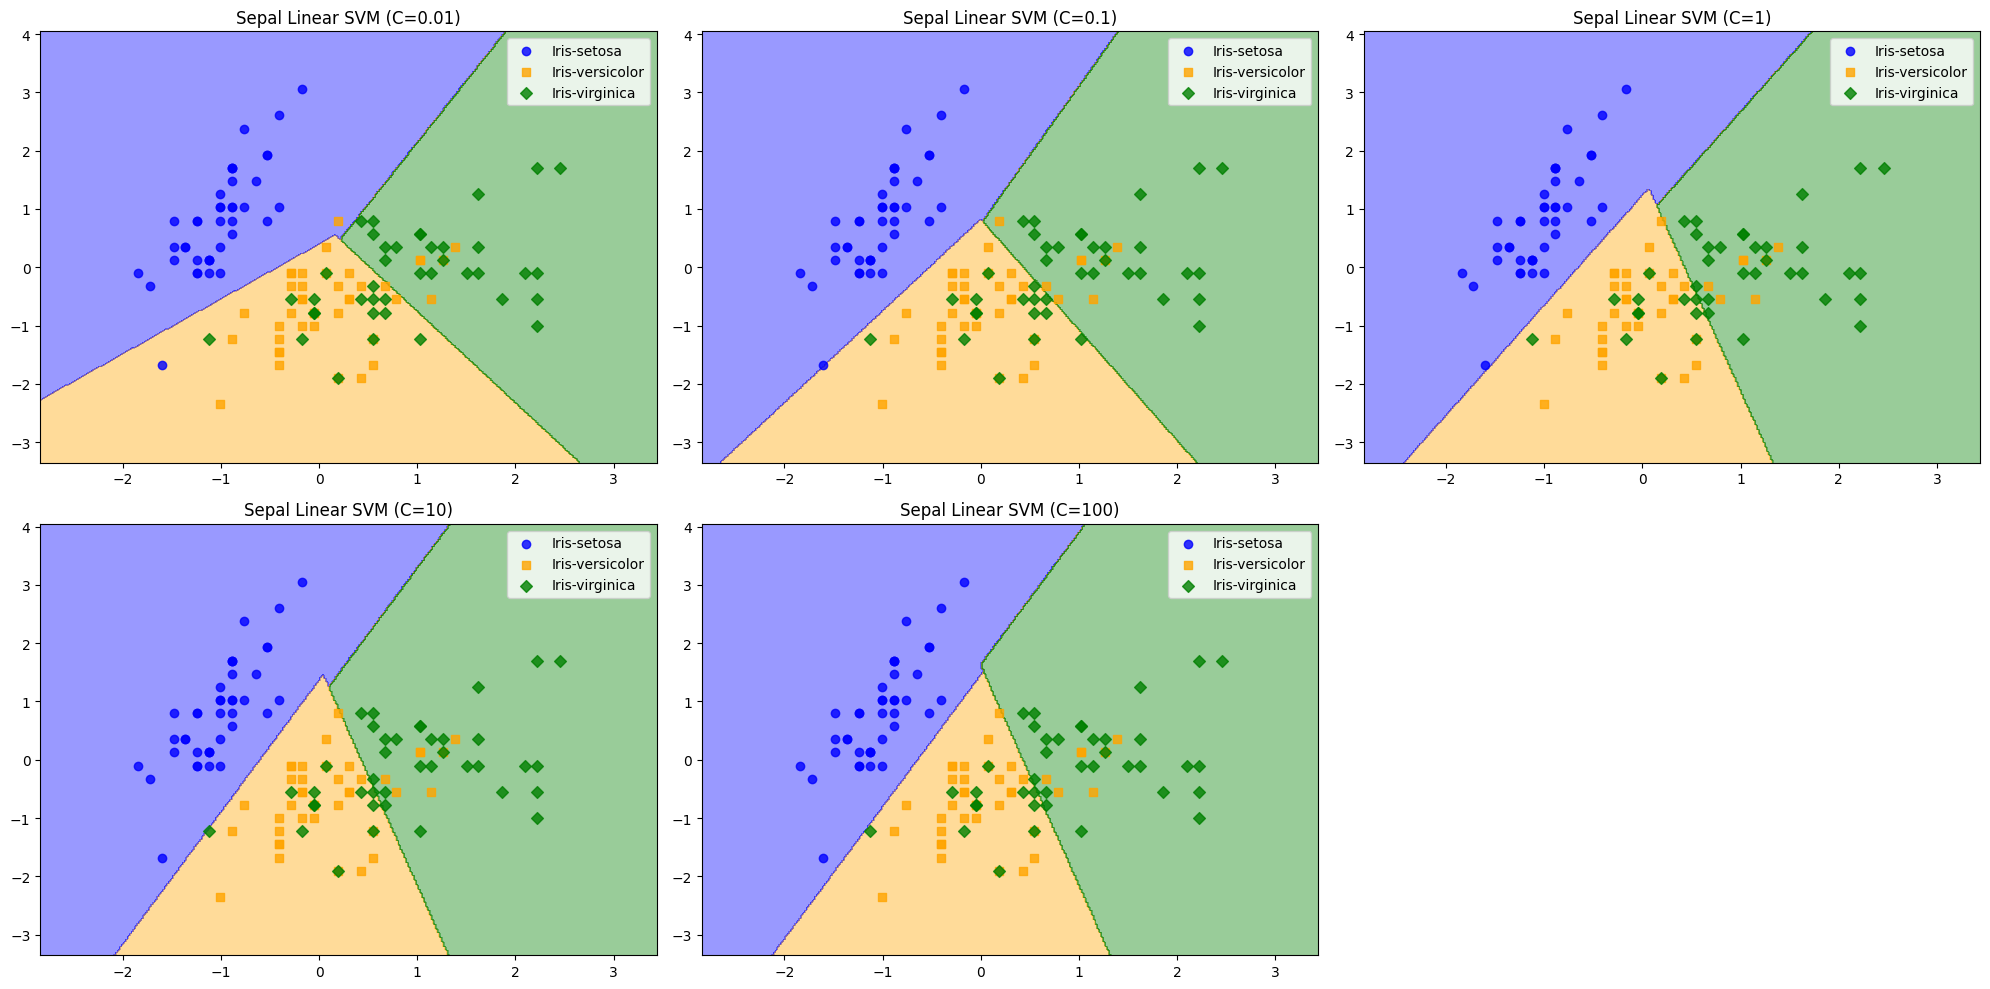

In [15]:
plt.figure(figsize=(20, 10))
grid = [0.01, 0.1, 1, 10, 100]

for i, cost in enumerate(grid, 1):
    model = svm.SVC(kernel='linear', C=cost)
    model.fit(X_sepal_train_std, y_train)
    plt.subplot(2, 3, i)
    plot_decision_regions(X_sepal_train_std, y_train, classifier=model, title=f"Sepal Linear SVM (C={cost})")
plt.tight_layout()
plt.show()

In [16]:
model = svm.SVC(kernel='linear')
model.fit(X_petal_train_std, y_train)
y_pred = model.predict(X_petal_test_std)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


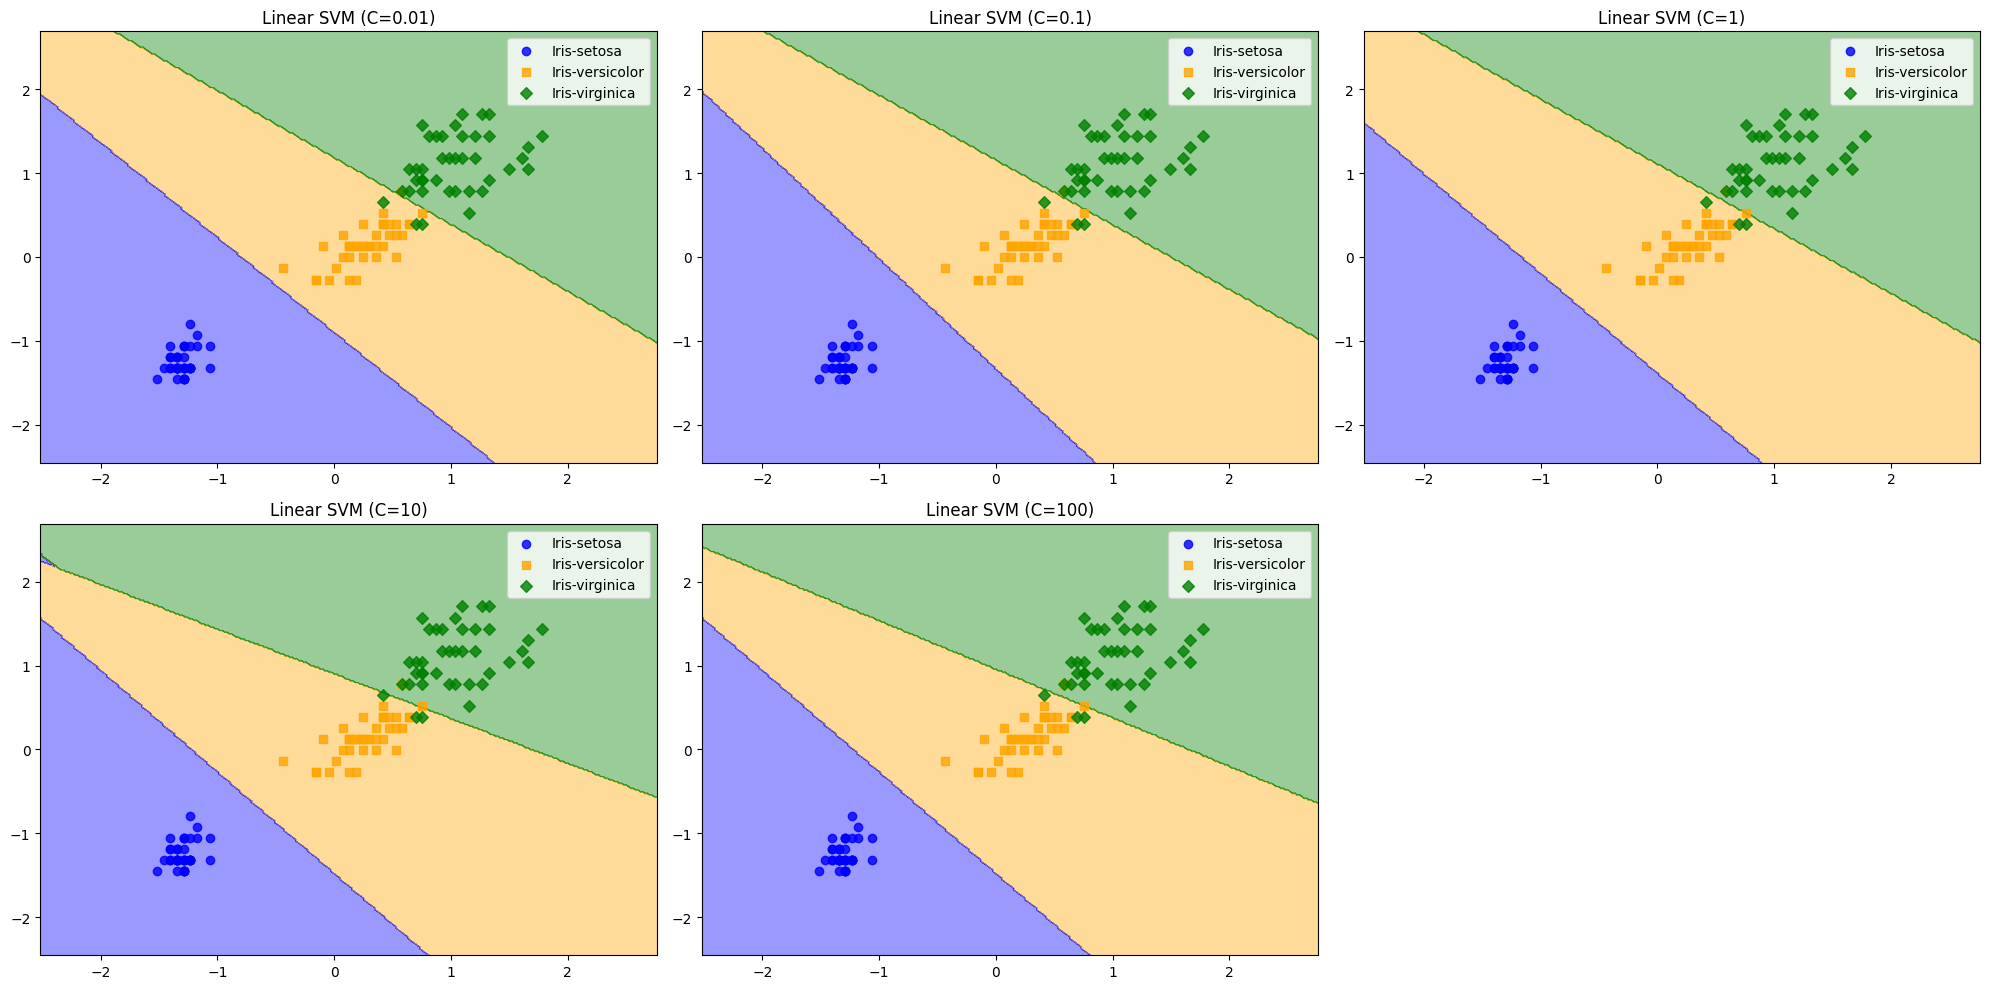

In [17]:
plt.figure(figsize=(20, 10))

for i, cost in enumerate(grid, 1):
    model = svm.SVC(kernel='linear', C=cost)
    model.fit(X_petal_train_std, y_train)
    plt.subplot(2, 3, i)
    plot_decision_regions(X_petal_train_std, y_train, classifier=model, title=f"Linear SVM (C={cost})")
plt.tight_layout()
plt.show()

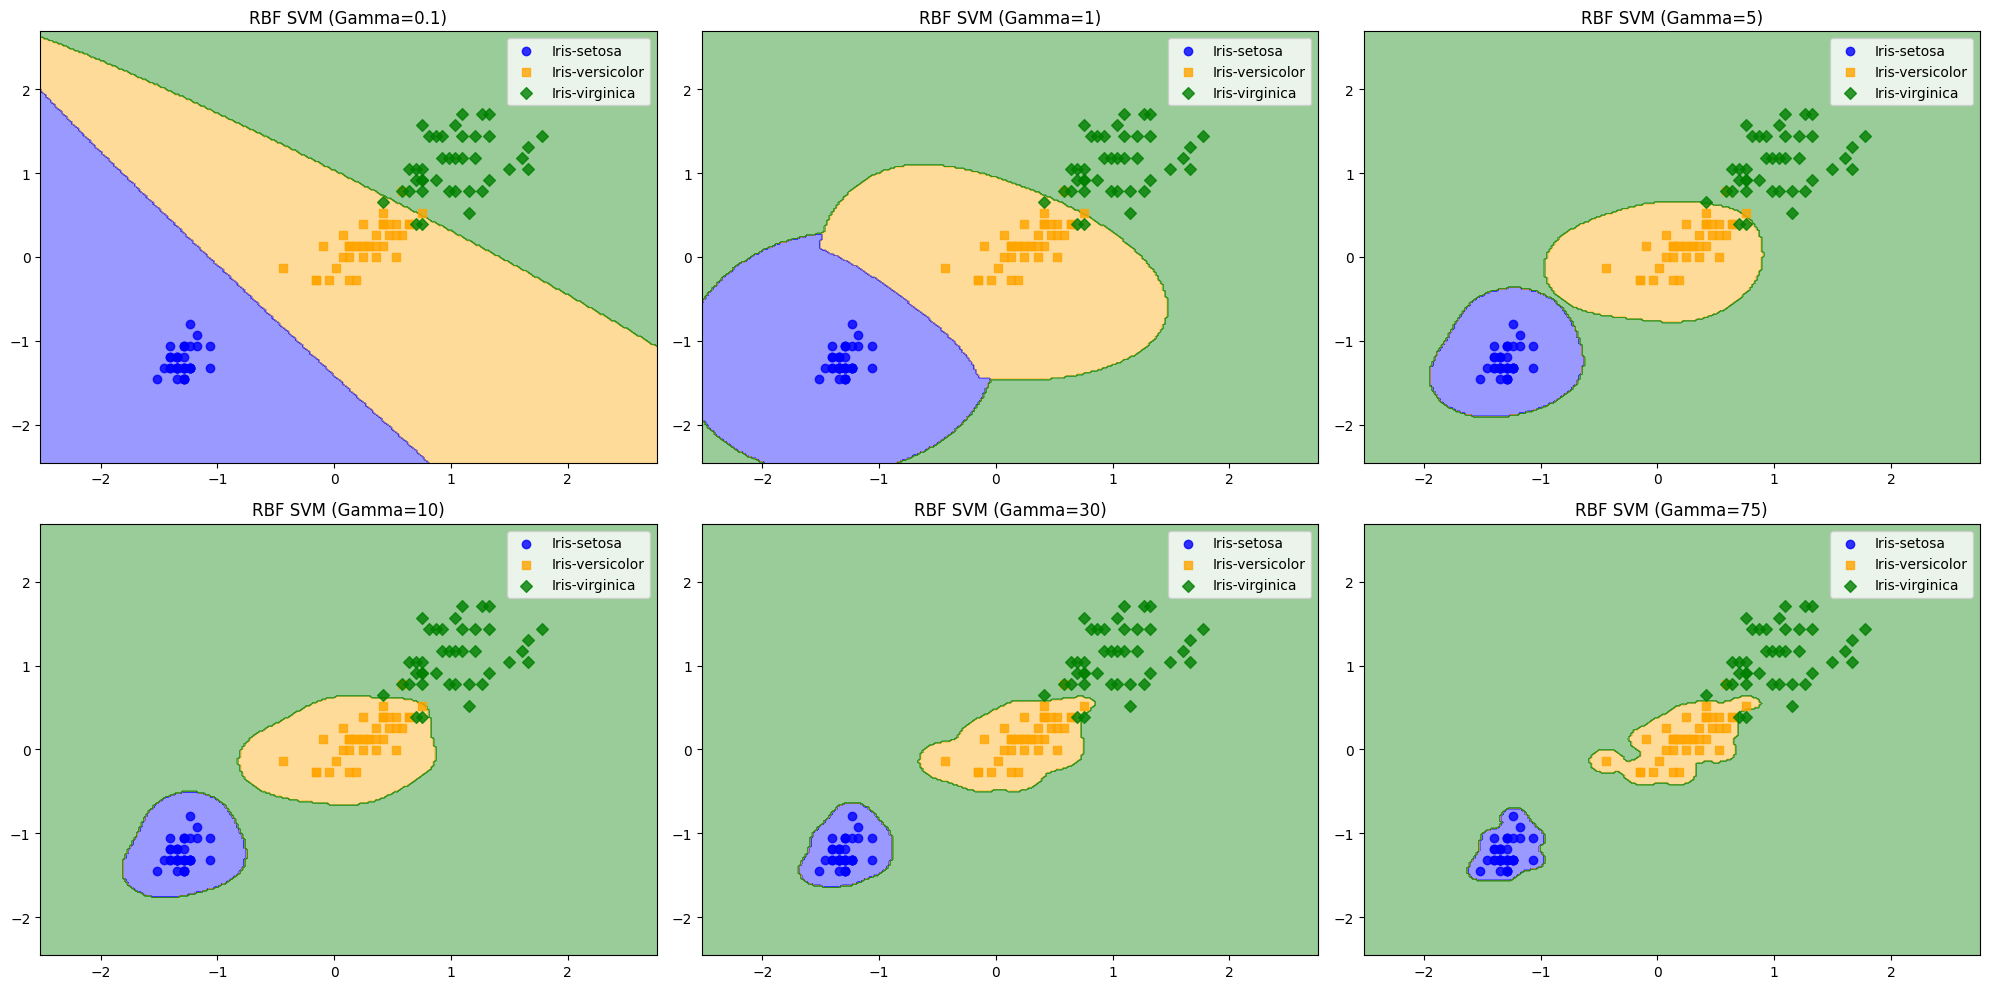

In [18]:
gamma_values = [0.1, 1, 5, 10, 30, 75]
# Plot decision boundaries for each gamma value
plt.figure(figsize=(20, 10))

for i, gamma in enumerate(gamma_values, 1):
    # Train SVM with RBF kernel
    clf_rbf = svm.SVC(kernel='rbf', gamma=gamma)
    clf_rbf.fit(X_petal_train_std, y_train)

    plt.subplot(2, 3, i)
    plot_decision_regions(X_petal_train_std, y_train, classifier=clf_rbf, title=f'RBF SVM (Gamma={gamma})')

plt.tight_layout()
plt.show()

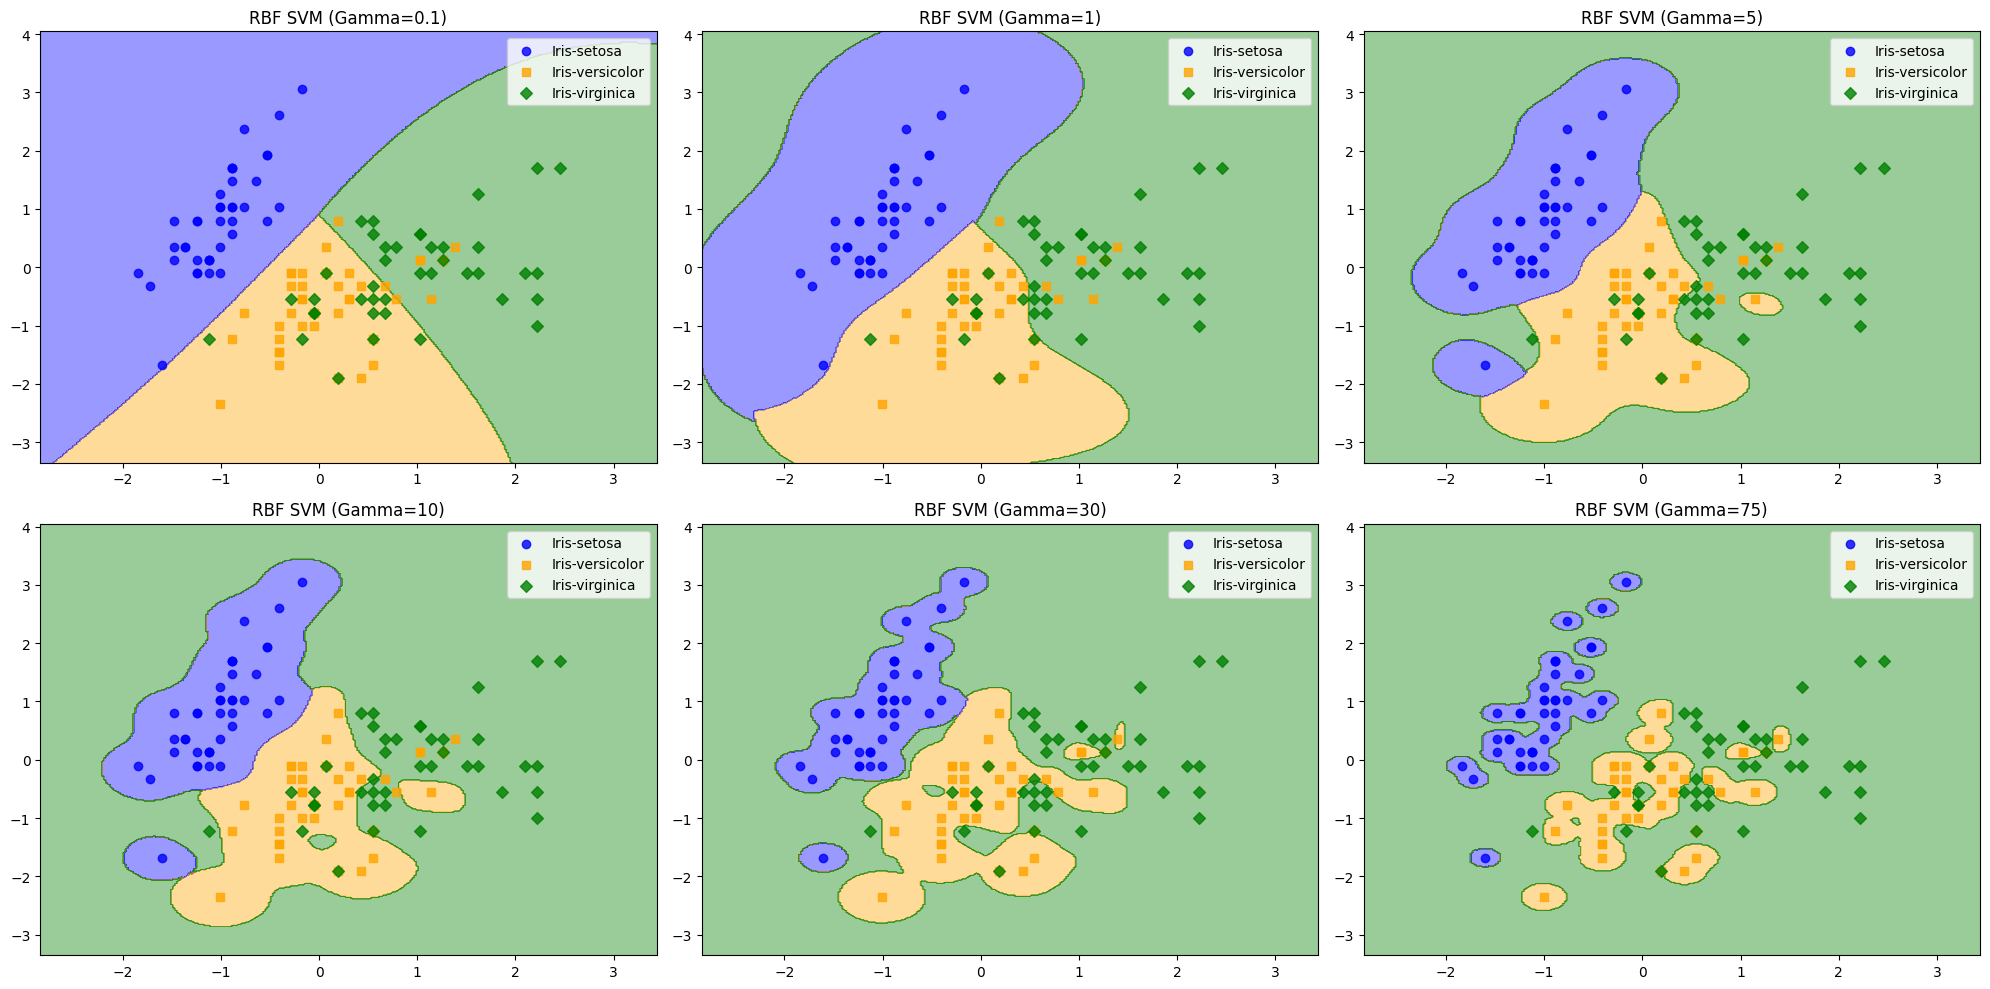

In [19]:
plt.figure(figsize=(20, 10))

for i, gamma in enumerate(gamma_values, 1):
    # Train SVM with RBF kernel
    clf_rbf = svm.SVC(kernel='rbf', gamma=gamma)
    clf_rbf.fit(X_sepal_train_std, y_train)

    plt.subplot(2, 3, i)
    plot_decision_regions(X_sepal_train_std, y_train, classifier=clf_rbf, title=f'RBF SVM (Gamma={gamma})')

plt.tight_layout()
plt.show()

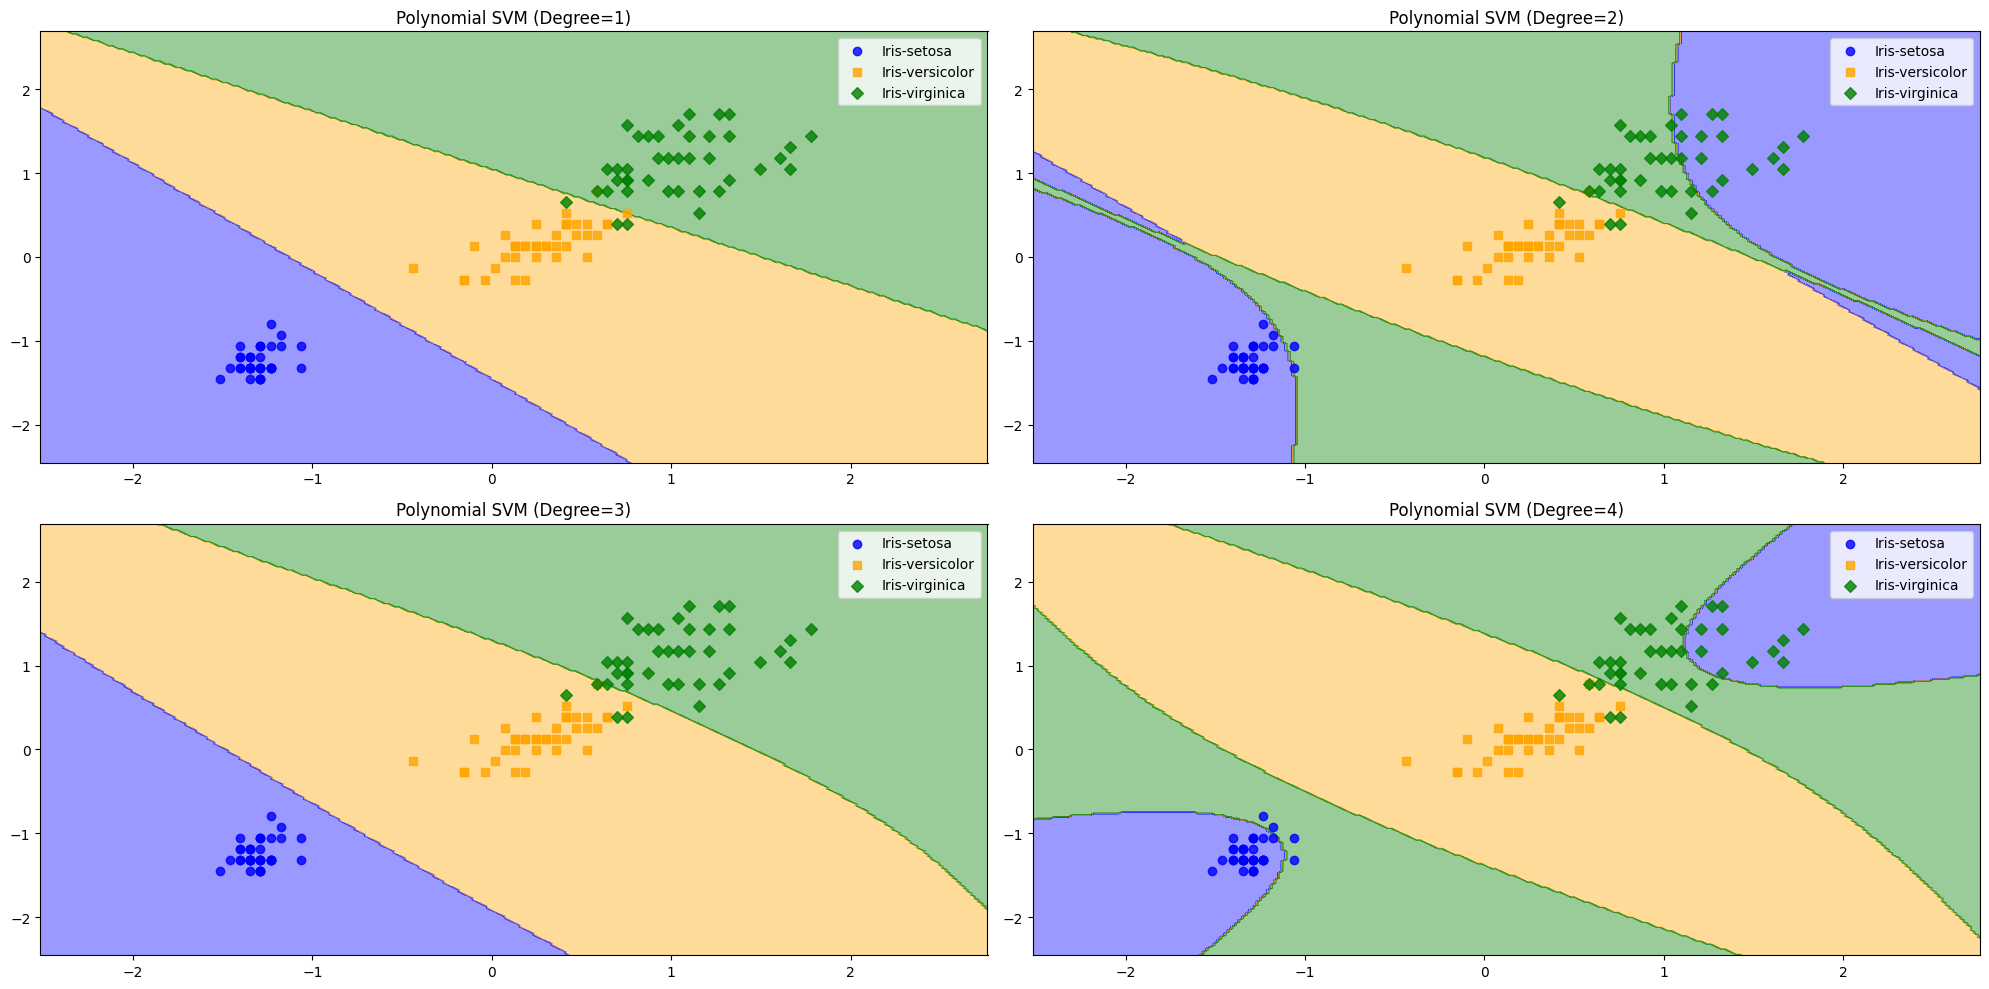

In [20]:
degree_grid = [1, 2, 3, 4]
# Plot decision boundaries for each degree value
plt.figure(figsize=(20, 10))

for i, degree in enumerate(degree_grid, 1):
    # Train SVM with RBF kernel
    clf_rbf = svm.SVC(kernel='poly', degree=degree)
    clf_rbf.fit(X_petal_train_std, y_train)

    plt.subplot(2, 2, i)
    plot_decision_regions(X_petal_train_std, y_train, classifier=clf_rbf, title=f'Polynomial SVM (Degree={degree})')

plt.tight_layout()
plt.show()

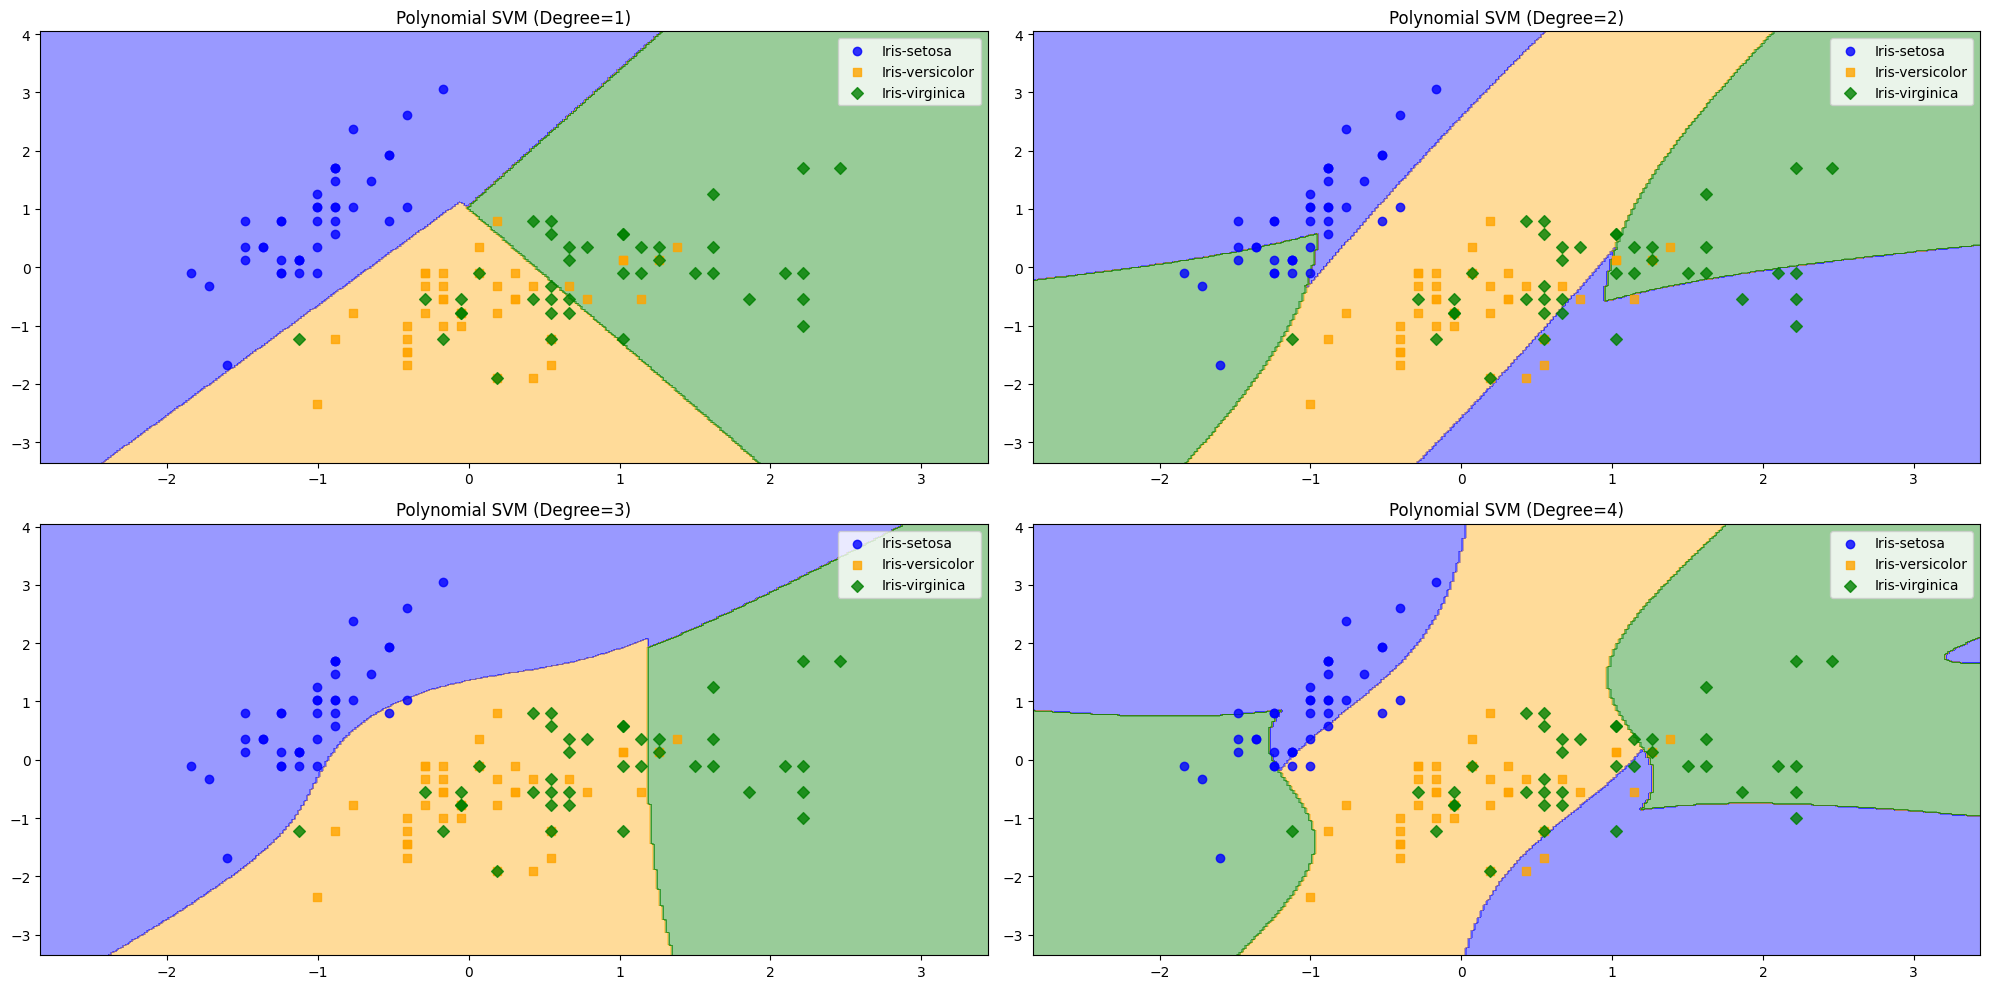

In [21]:
# Plot decision boundaries for each degree value
plt.figure(figsize=(20, 10))

for i, degree in enumerate(degree_grid, 1):
    # Train SVM with RBF kernel
    clf_rbf = svm.SVC(kernel='poly', degree=degree)
    clf_rbf.fit(X_sepal_train_std, y_train)

    plt.subplot(2, 2, i)
    plot_decision_regions(X_sepal_train_std, y_train, classifier=clf_rbf, title=f'Polynomial SVM (Degree={degree})')

plt.tight_layout()
plt.show()